# Election Data Engineering Pipeline + Audit Analytics

Notebook นี้จัดใหม่ให้เป็น step แบบ Data Engineering อ่านง่ายขึ้น โดยเริ่มจาก raw CSV แล้วสร้างไฟล์ final สำหรับ dashboard/map พร้อมไฟล์ audit เพิ่มเติม

**ภาพรวมขั้นตอน**
1. Setup config และรายชื่อพรรคมาตรฐาน
2. Load raw CSV
3. Clean / normalize ข้อมูล
4. สร้าง `unit_index` และเติม latitude/longitude
5. Build final table สำหรับ partylist และ constituency
6. Join `normal_ballots.csv` + `advanced_ballots.csv` เพื่อเพิ่มจำนวนบัตรทั้งเลือกตั้งปกติและล่วงหน้า
7. สร้าง audit features, แยกระดับ `review` / `high_review`, และแยก `serious_flags`
8. Export CSV final และไฟล์ audit แยกประเภท


## Step 0 — Import libraries และตั้งค่า path

Cell นี้รวม package ที่ใช้, path ไฟล์ input/output และปิด warning ที่ไม่จำเป็น เพื่อให้ output อ่านง่าย


In [ ]:
from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

INPUT_FILES = {
    "partylist_normal": "party_list.csv",
    "partylist_advance": "party_list2.csv",
    "constituency_normal": "constituency.csv",
    "constituency_advance": "constituency2.csv",
    "location_66": "election_locations_66.csv",
    "normal_ballots": "normal_ballots.csv",
    "advanced_ballots": "advanced_ballots.csv",
    "election_scores_66": "election_scores_2566.csv",
}

OUTPUT_FILES = {
    "final": "final_from_pipeline_clean.csv",
    "final_with_ballots": "final_with_ballots_clean.csv",
    "features": "election_audit_features_clean.csv",
    "audit_table": "audit_table_clean.csv",
    "audit_review_units": "audit_review_units_clean.csv",
    "audit_high_review_units": "audit_high_review_units_clean.csv",
    "audit_serious_flags": "audit_serious_flags_clean.csv",
    "audit_flag_summary": "audit_flag_summary_clean.csv",
    "audit_level_category_summary": "audit_level_category_summary_clean.csv",
    "district_summary": "district_summary_clean.csv",
    "subdistrict_summary": "subdistrict_summary_clean.csv",
    "final_66": "final_2566_clean.csv",
    "final_66_with_ballots": "final_with_ballots_2566_clean.csv",
    "ballot_long_66": "ballot_long_2566_clean.csv",
    "final_all_years": "final_2566_2569_combined_clean.csv",
    "final_with_ballots_all_years": "final_with_ballots_2566_2569_combined_clean.csv",
}

for name, path in INPUT_FILES.items():
    print(f"{name:22s}: {name:35s} exists={path}")


partylist_normal      : partylist_normal                    exists=party_list.csv
partylist_advance     : partylist_advance                   exists=party_list2.csv
constituency_normal   : constituency_normal                 exists=constituency.csv
constituency_advance  : constituency_advance                exists=constituency2.csv
location_66           : location_66                         exists=election_locations_66.csv
normal_ballots        : normal_ballots                      exists=normal_ballots.csv
advanced_ballots      : advanced_ballots                    exists=advanced_ballots.csv
election_scores_66    : election_scores_66                  exists=election_scores_2566.csv


## Step 1 — กำหนด master data

ส่วนนี้คือข้อมูลอ้างอิงหลัก เช่น รายชื่อพรรคทั้งหมด, สีพรรค, column ที่ต้องการในไฟล์ final และชื่อ column จำนวนบัตร


In [ ]:
PARTY_NAMES = ['ไทยทรัพย์ทวี','เพื่อชาติไทย','ใหม่','มิติใหม่','รวมใจไทย','รวมไทยสร้างชาติ','พลวัต','ประชาธิปไตยใหม่','เพื่อไทย','ทางเลือกใหม่','เศรษฐกิจ','เสรีรวมไทย','รวมพลังประชาชน','ท้องที่ไทย','อนาคตไทย','พลังเพื่อไทย','ไทยชนะ','พลังสังคมใหม่','สังคมประชาธิปไตยใหม่','ฟิวชัน','ไทรวมพลัง','ก้าวอิสระ','ปวงชนไทย','วิชชั่นใหม่','เพื่อชีวิตใหม่','คลองไทย','ประชาธิปัตย์','ไทยก้าวหน้า','ไทยภักดี','แรงงานสร้างชาติ','ประชากรไทย','ครูไทยเพื่อประชาชน','ประชาชาติ','สร้างอนาคตไทย','รักชาติ','ไทยพร้อม','ภูมิใจไทย','พลังธรรมใหม่','กรีน','ไทยธรรม','แผ่นดินธรรม','กล้าธรรม','พลังประชารัฐ','โอกาสใหม่','เป็นธรรม','ประชาชน','ประชาไทย','ไทยสร้างไทย','ไทยก้าวใหม่','ประชาอาสาชาติ','พร้อม','เครือข่ายชาวนาแห่งประเทศไทย','ไทยพิทักษ์ธรรม','ความหวังใหม่','ไทยรวมไทย','เพื่อบ้านเมือง','พลังไทยรักชาติ']

PARTY_NO_MAP = {name: i + 1 for i, name in enumerate(PARTY_NAMES)}
PARTY_NAME_MAP = {i + 1: name for i, name in enumerate(PARTY_NAMES)}

PARTY_COLORS = {
    "ประชาชน": [255, 120, 0, 190],
    "เพื่อไทย": [220, 20, 60, 190],
    "ภูมิใจไทย": [30, 144, 255, 190],
    "ประชาธิปัตย์": [70, 130, 180, 190],
    "รวมไทยสร้างชาติ": [25, 25, 112, 190],
    "พลังประชารัฐ": [0, 80, 180, 190],
    "กล้าธรรม": [60, 179, 113, 190],
    "ไทยสร้างไทย": [128, 0, 128, 190],
}
DEFAULT_COLOR = [120, 120, 120, 160]

NORMALIZE_PARTY_ALIASES = {
    "สังคมประชาธิปไตย": "สังคมประชาธิปไตยใหม่",
    'ไทยรวมพลัง': 'ไทรวมพลัง'
}

SUBDISTRICT_ALIASES = {
    "บ้านแม่ข่า": "แม่ข่า",
    "ทต.บ้านแม่ข่า": "แม่ข่า",
    "เวียงฝาง": "เวียง",
    "ทต.เวียงฝาง": "เวียง",
    "ตำบลบ้านแม่ข่า": "แม่ข่า",
    "ตำบลเวียงฝาง": "เวียง",
}

FINAL_COLUMNS = [
    "unit_index", "year", "election_type", "unit_type", "district", "subdistrict",
    "village_no", "precinct_no", "set_no", "latitude", "longitude",
    "winner_party", "winner_candidate", "winner_votes", "runner_up_party",
    "runner_up_votes", "margin", "total_votes_in_file", "results", "color", "display_name"
]

BALLOT_COLUMNS = [
    "eligible_voters", "appeared_voters", "allocated_ballots", "used_ballots",
    "valid_ballots", "invalid_ballots", "no_vote_ballots", "remaining_ballots"
]

print("Number of parties:", len(PARTY_NAMES))


Number of parties: 57


## Step 2 — Helper functions สำหรับ clean data

Function กลุ่มนี้ใช้ซ้ำหลายจุด เช่น อ่าน CSV แบบกัน BOM, clean text, normalize ชื่อพรรค/ตำบล, แปลงตัวเลข และหารแบบกันหารศูนย์


In [ ]:
def read_csv_clean(path: Path) -> pd.DataFrame:
    """Read UTF-8 CSV and remove hidden BOM/extra spaces from column names."""
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = [str(c).replace("﻿", "").strip() for c in df.columns]
    return df


def clean_text(value):
    """Trim text and collapse duplicated spaces. Empty text becomes NaN."""
    if pd.isna(value):
        return np.nan
    text = " ".join(str(value).strip().split())
    return text if text else np.nan


def normalize_party(name):
    """Map party aliases to the master party list."""
    name = clean_text(name)
    if pd.isna(name):
        return name
    return NORMALIZE_PARTY_ALIASES.get(name, name)


def normalize_subdistrict(name):
    """Remove Thai administrative prefixes and map aliases."""
    name = clean_text(name)
    if pd.isna(name):
        return name

    for prefix in ["ตำบล", "ต.", "แขวง", "เทศบาลตำบล", "ทต."]:
        if str(name).startswith(prefix):
            name = str(name).replace(prefix, "", 1).strip()

    return SUBDISTRICT_ALIASES.get(name, name)


def to_int_or_nan(value):
    """Convert value to int; invalid values become NaN."""
    if pd.isna(value):
        return np.nan
    try:
        text = str(value).replace(",", "").strip()
        return int(float(text))
    except Exception:
        return np.nan


def safe_div(numerator, denominator):
    """Vectorized division that returns NaN when denominator is zero/missing."""
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid_denominator = denominator.fillna(0).astype(float) != 0
    return np.where(valid_denominator, numerator.astype(float) / denominator.astype(float), np.nan)


def stable_jitter(key: str, scale: float = 0.00018):
    """Create deterministic small lat/lng jitter from a string key."""
    digest = hashlib.md5(str(key).encode("utf-8")).hexdigest()
    a = int(digest[:8], 16) / 0xFFFFFFFF
    b = int(digest[8:16], 16) / 0xFFFFFFFF
    return (a - 0.5) * scale, (b - 0.5) * scale


## Step 3 — Load raw CSV

อ่านไฟล์ raw ทั้งหมดเข้ามาเก็บเป็น DataFrame แยกตามชนิดข้อมูล เพื่อง่ายต่อการ debug


In [ ]:
party_normal_raw = read_csv_clean(INPUT_FILES["partylist_normal"])
party_advance_raw = read_csv_clean(INPUT_FILES["partylist_advance"])
const_normal_raw = read_csv_clean(INPUT_FILES["constituency_normal"])
const_advance_raw = read_csv_clean(INPUT_FILES["constituency_advance"])
location_66_raw = read_csv_clean(INPUT_FILES["location_66"])
normal_ballots_raw = read_csv_clean(INPUT_FILES["normal_ballots"])
advanced_ballots_raw = read_csv_clean(INPUT_FILES["advanced_ballots"])

raw_tables = {
    "party_normal_raw": party_normal_raw,
    "party_advance_raw": party_advance_raw,
    "const_normal_raw": const_normal_raw,
    "const_advance_raw": const_advance_raw,
    "location_66_raw": location_66_raw,
    "normal_ballots_raw": normal_ballots_raw,
    "advanced_ballots_raw": advanced_ballots_raw,
}

for name, df in raw_tables.items():
    print(f"{name:22s}: {df.shape}")


party_normal_raw      : (16245, 10)
party_advance_raw     : (513, 7)
const_normal_raw      : (2565, 11)
const_advance_raw     : (81, 8)
location_66_raw       : (95249, 12)
normal_ballots_raw    : (286, 26)
advanced_ballots_raw  : (10, 12)


## Step 4 — สร้าง `unit_index`

`unit_index` เป็น key หลักสำหรับรวมข้อมูลข้ามไฟล์

- หน่วยปกติ: จังหวัด + เขต + อำเภอ + ตำบล + หมู่ + หมายเลขหน่วย
- หน่วยล่วงหน้า: จังหวัด + เขต + ชุดล่วงหน้า


In [ ]:
def make_unit_index(row, is_advance=False):
    province_id = int(float(row.get("รหัสจังหวัด", 50)))
    province = clean_text(row.get("จังหวัด", "เชียงใหม่"))
    district_no = int(float(row.get("เขต", 7)))

    if is_advance:
        set_no = int(float(row["set_no"]))
        return f"{province_id}_{province}_{district_no}_ล่วงหน้านอกเขตและนอกราชอาณาจักร_{set_no}"

    amphoe = clean_text(row["อำเภอ"])
    subdistrict = clean_text(row["ตำบล"])
    village_no = clean_text(row["หมู่"])
    precinct_no = int(float(row["หมายเลขหน่วยเลือกตั้ง"]))

    return f"{province_id}_{province}_{district_no}_{amphoe}_{subdistrict}_{village_no}_{precinct_no}"


## Step 5 — เตรียม latitude/longitude lookup

ตำแหน่งปี 66 ถูกใช้เป็น reference เพื่อเติมพิกัดให้หน่วยปี 69 โดย match ระดับอำเภอ/ตำบล และลำดับหน่วย จากนั้น jitter จุดที่ซ้ำกันเล็กน้อยเพื่อให้ scatter/map กดดูได้ง่ายขึ้น


In [ ]:
def prepare_location_lookup(unit_df: pd.DataFrame, loc66: pd.DataFrame) -> pd.DataFrame:
    """Create unit_index -> latitude/longitude table from 2566 location reference."""
    loc = loc66.copy()
    loc = loc[loc["provinceid"].eq(50)].copy()
    loc = loc[loc["districtname"].isin(["ฝาง", "แม่อาย", "ไชยปราการ"])].copy()

    loc["district_norm"] = loc["districtname"].map(clean_text)
    loc["subdistrict_norm"] = loc["subdistrictname"].map(normalize_subdistrict)
    loc["lat_changable"] = pd.to_numeric(loc["lat_changable"], errors="coerce")
    loc["lng_changable"] = pd.to_numeric(loc["lng_changable"], errors="coerce")
    loc = loc.dropna(subset=["lat_changable", "lng_changable"])
    loc = loc.sort_values(["district_norm", "subdistrict_norm", "unitid"]).reset_index(drop=True)
    loc["loc_seq"] = loc.groupby(["district_norm", "subdistrict_norm"]).cumcount()

    units = unit_df.copy()
    units["district_norm"] = units["อำเภอ"].map(clean_text)
    units["subdistrict_norm"] = units["ตำบล"].map(normalize_subdistrict)
    units = units.sort_values(["district_norm", "subdistrict_norm", "หมู่", "หมายเลขหน่วยเลือกตั้ง"]).reset_index(drop=True)
    units["unit_seq"] = units.groupby(["district_norm", "subdistrict_norm"]).cumcount()

    # 1) Match by sequence within district/subdistrict
    exact = loc[["district_norm", "subdistrict_norm", "loc_seq", "lat_changable", "lng_changable"]]
    exact = exact.rename(columns={"loc_seq": "unit_seq"})
    units = units.merge(exact, on=["district_norm", "subdistrict_norm", "unit_seq"], how="left")

    # 2) Fallback to subdistrict centroid if exact sequence is missing
    centroid = loc.groupby(["district_norm", "subdistrict_norm"], as_index=False).agg(
        centroid_lat=("lat_changable", "mean"),
        centroid_lng=("lng_changable", "mean"),
    )
    units = units.merge(centroid, on=["district_norm", "subdistrict_norm"], how="left")
    units["latitude"] = units["lat_changable"].fillna(units["centroid_lat"])
    units["longitude"] = units["lng_changable"].fillna(units["centroid_lng"])

    # 3) Jitter duplicated/nearby points deterministically
    for i, row in units.iterrows():
        if pd.notna(row["latitude"]) and pd.notna(row["longitude"]):
            dlat, dlng = stable_jitter(row["unit_index"])
            units.at[i, "latitude"] = float(row["latitude"]) + dlat
            units.at[i, "longitude"] = float(row["longitude"]) + dlng

    return units[["unit_index", "latitude", "longitude"]]


normal_units = party_normal_raw[["รหัสจังหวัด", "จังหวัด", "เขต", "อำเภอ", "ตำบล", "หมู่", "หมายเลขหน่วยเลือกตั้ง"]].drop_duplicates().copy()
normal_units["unit_index"] = normal_units.apply(lambda r: make_unit_index(r, is_advance=False), axis=1)

location_lookup = prepare_location_lookup(normal_units, location_66_raw)
print(location_lookup.shape)
location_lookup.head()


(285, 3)


,unit_index,latitude,longitude
0,50_เชียงใหม่_7_ฝาง_ม่อนปิ่น_1_1,19.915950,99.180337
1,50_เชียงใหม่_7_ฝาง_ม่อนปิ่น_10_12,19.912407,99.175720
2,50_เชียงใหม่_7_ฝาง_ม่อนปิ่น_10_13,19.915833,99.164854
3,50_เชียงใหม่_7_ฝาง_ม่อนปิ่น_11_14,19.904318,99.166150
4,50_เชียงใหม่_7_ฝาง_ม่อนปิ่น_12_15,19.964939,99.099788


## Step 6 — Function สรุปผลคะแนนต่อหน่วย

ใช้แปลงคะแนนรายพรรค/รายผู้สมัครให้เหลือ 1 แถวต่อหน่วย พร้อม winner, runner-up, margin และ `results` แบบ JSON สำหรับกดดูอันดับทั้งหมดใน dashboard


In [ ]:
def summarize_results(records, election_type):
    """Summarize list of vote records into winner/runner-up/result JSON."""
    if not records:
        return pd.Series({
            "winner_party": np.nan,
            "winner_candidate": np.nan,
            "winner_votes": 0,
            "runner_up_party": np.nan,
            "runner_up_votes": 0,
            "margin": 0,
            "total_votes_in_file": 0,
            "results": "[]",
        })

    rows = sorted(records, key=lambda r: (-int(r.get("votes", 0)), str(r.get("party_no", r.get("candidate_no", "")))))
    winner = rows[0]
    runner = rows[1] if len(rows) > 1 else {"party": np.nan, "votes": 0}
    total_votes = int(sum(int(r.get("votes", 0)) for r in rows))

    return pd.Series({
        "winner_party": winner.get("party"),
        "winner_candidate": winner.get("candidate") if election_type == "constituency" else np.nan,
        "winner_votes": int(winner.get("votes", 0)),
        "runner_up_party": runner.get("party"),
        "runner_up_votes": int(runner.get("votes", 0)),
        "margin": int(winner.get("votes", 0)) - int(runner.get("votes", 0)),
        "total_votes_in_file": total_votes,
        "results": json.dumps(rows, ensure_ascii=False),
    })


## Step 7 — Build final table: partylist ปกติ

สร้างข้อมูล partylist แบบหน่วยปกติ โดยเติมพรรคที่คะแนนหายให้ครบ 57 พรรค แล้วรวมเป็น 1 แถวต่อหน่วย


In [ ]:
def build_partylist_normal(df: pd.DataFrame, loc_lookup: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ชื่อพรรค"] = df["ชื่อพรรค"].map(normalize_party)
    df["คะแนน"] = pd.to_numeric(df["คะแนน"], errors="coerce").fillna(0).astype(int)
    df["unit_index"] = df.apply(lambda r: make_unit_index(r, is_advance=False), axis=1)

    meta_cols = ["unit_index", "รหัสจังหวัด", "จังหวัด", "เขต", "อำเภอ", "ตำบล", "หมู่", "หมายเลขหน่วยเลือกตั้ง"]
    meta = df[meta_cols].drop_duplicates("unit_index").copy()

    units = meta[["unit_index"]].drop_duplicates()
    party_master = pd.DataFrame({"หมายเลขพรรค": range(1, len(PARTY_NAMES) + 1), "ชื่อพรรค": PARTY_NAMES})
    full = units.merge(party_master, how="cross")

    votes = df.groupby(["unit_index", "หมายเลขพรรค", "ชื่อพรรค"], as_index=False)["คะแนน"].sum()
    full = full.merge(votes, on=["unit_index", "หมายเลขพรรค", "ชื่อพรรค"], how="left")
    full["คะแนน"] = full["คะแนน"].fillna(0).astype(int)

    rows = []
    for unit_index, g in full.groupby("unit_index"):
        records = [
            {"party_no": int(r["หมายเลขพรรค"]), "party": r["ชื่อพรรค"], "votes": int(r["คะแนน"])}
            for _, r in g.iterrows()
        ]
        s = summarize_results(records, "partylist")
        m = meta[meta["unit_index"].eq(unit_index)].iloc[0]
        s["unit_index"] = unit_index
        s["year"] = 2569
        s["election_type"] = "partylist"
        s["unit_type"] = "normal_precinct"
        s["district"] = clean_text(m["อำเภอ"])
        s["subdistrict"] = clean_text(m["ตำบล"])
        s["village_no"] = clean_text(m["หมู่"])
        s["precinct_no"] = int(m["หมายเลขหน่วยเลือกตั้ง"])
        s["set_no"] = np.nan
        rows.append(s)

    out = pd.DataFrame(rows).merge(loc_lookup, on="unit_index", how="left")
    out["color"] = out["winner_party"].map(lambda x: PARTY_COLORS.get(x, DEFAULT_COLOR))
    out["display_name"] = out.apply(
        lambda r: f"ปี {r['year']} / partylist / {r['district']} / {r['subdistrict']} / {r['village_no']} / หน่วย {int(r['precinct_no'])}",
        axis=1,
    )
    return out[FINAL_COLUMNS]


## Step 8 — Build final table: partylist ล่วงหน้า

ข้อมูลล่วงหน้าไม่มี latitude/longitude เพราะไม่ใช่หน่วยเลือกตั้งเชิงพื้นที่ จึงเก็บเป็น `advance_set` และใช้ `set_no` แทน


In [ ]:
def build_partylist_advance(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().rename(columns={"ชุด": "หมายเลขชุด"})
    df["ชื่อพรรค"] = df["ชื่อพรรค"].map(normalize_party)
    df["คะแนน"] = pd.to_numeric(df["คะแนน"], errors="coerce").fillna(0).astype(int)
    df["set_no"] = df["หมายเลขชุด"].astype(int)
    df["unit_index"] = df.apply(lambda r: make_unit_index(r, is_advance=True), axis=1)

    party_master = pd.DataFrame({"หมายเลขพรรค": range(1, len(PARTY_NAMES) + 1), "ชื่อพรรค": PARTY_NAMES})
    units = df[["unit_index", "set_no", "รหัสจังหวัด", "จังหวัด", "เขต"]].drop_duplicates()
    full = units[["unit_index"]].merge(party_master, how="cross")

    votes = df.groupby(["unit_index", "หมายเลขพรรค", "ชื่อพรรค"], as_index=False)["คะแนน"].sum()
    full = full.merge(votes, on=["unit_index", "หมายเลขพรรค", "ชื่อพรรค"], how="left")
    full["คะแนน"] = full["คะแนน"].fillna(0).astype(int)

    rows = []
    for unit_index, g in full.groupby("unit_index"):
        records = [
            {"party_no": int(r["หมายเลขพรรค"]), "party": r["ชื่อพรรค"], "votes": int(r["คะแนน"])}
            for _, r in g.iterrows()
        ]
        s = summarize_results(records, "partylist")
        m = units[units["unit_index"].eq(unit_index)].iloc[0]
        s["unit_index"] = unit_index
        s["year"] = 2569
        s["election_type"] = "partylist"
        s["unit_type"] = "advance_set"
        s["district"] = f"เขต {int(m['เขต'])}"
        s["subdistrict"] = np.nan
        s["village_no"] = np.nan
        s["precinct_no"] = np.nan
        s["set_no"] = int(m["set_no"])
        s["latitude"] = np.nan
        s["longitude"] = np.nan
        rows.append(s)

    out = pd.DataFrame(rows)
    out["color"] = out["winner_party"].map(lambda x: PARTY_COLORS.get(x, DEFAULT_COLOR))
    out["display_name"] = out.apply(lambda r: f"ปี {r['year']} / partylist / ล่วงหน้า / ชุด {int(r['set_no'])}", axis=1)
    return out[FINAL_COLUMNS]


## Step 9 — Build final table: constituency ปกติ

ข้อมูล constituency เป็นคะแนนรายผู้สมัคร จึงเก็บทั้ง `winner_party` และ `winner_candidate`


In [ ]:
def build_constituency_normal(df: pd.DataFrame, loc_lookup: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ชื่อพรรค"] = df["ชื่อพรรค"].map(normalize_party)
    df["คะแนน"] = pd.to_numeric(df["คะแนน"], errors="coerce").fillna(0).astype(int)
    df["unit_index"] = df.apply(lambda r: make_unit_index(r, is_advance=False), axis=1)

    meta_cols = ["unit_index", "รหัสจังหวัด", "จังหวัด", "เขต", "อำเภอ", "ตำบล", "หมู่", "หมายเลขหน่วยเลือกตั้ง"]
    meta = df[meta_cols].drop_duplicates("unit_index").copy()

    rows = []
    for unit_index, g in df.groupby("unit_index"):
        records = [
            {
                "candidate_no": int(r["หมายเลขผู้สมัคร"]),
                "candidate": clean_text(r["ชื่อผู้สมัคร"]),
                "party": r["ชื่อพรรค"],
                "votes": int(r["คะแนน"]),
            }
            for _, r in g.iterrows()
        ]
        s = summarize_results(records, "constituency")
        m = meta[meta["unit_index"].eq(unit_index)].iloc[0]
        s["unit_index"] = unit_index
        s["year"] = 2569
        s["election_type"] = "constituency"
        s["unit_type"] = "normal_precinct"
        s["district"] = clean_text(m["อำเภอ"])
        s["subdistrict"] = clean_text(m["ตำบล"])
        s["village_no"] = clean_text(m["หมู่"])
        s["precinct_no"] = int(m["หมายเลขหน่วยเลือกตั้ง"])
        s["set_no"] = np.nan
        rows.append(s)

    out = pd.DataFrame(rows).merge(loc_lookup, on="unit_index", how="left")
    out["color"] = out["winner_party"].map(lambda x: PARTY_COLORS.get(x, DEFAULT_COLOR))
    out["display_name"] = out.apply(
        lambda r: f"ปี {r['year']} / constituency / {r['district']} / {r['subdistrict']} / {r['village_no']} / หน่วย {int(r['precinct_no'])}",
        axis=1,
    )
    return out[FINAL_COLUMNS]


## Step 10 — Build final table: constituency ล่วงหน้า

เหมือน constituency ปกติ แต่ใช้ `set_no` แทนตำแหน่งหน่วยเลือกตั้ง


In [ ]:
def build_constituency_advance(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["ชื่อพรรค"] = df["ชื่อพรรค"].map(normalize_party)
    df["คะแนน"] = pd.to_numeric(df["คะแนน"], errors="coerce").fillna(0).astype(int)
    df["set_no"] = df["หมายเลขชุด"].astype(int)
    df["unit_index"] = df.apply(lambda r: make_unit_index(r, is_advance=True), axis=1)

    units = df[["unit_index", "set_no", "รหัสจังหวัด", "จังหวัด", "เขต"]].drop_duplicates()
    rows = []

    for unit_index, g in df.groupby("unit_index"):
        records = [
            {
                "candidate_no": int(r["หมายเลขผู้สมัคร"]),
                "candidate": clean_text(r["ชื่อผู้สมัคร"]),
                "party": r["ชื่อพรรค"],
                "votes": int(r["คะแนน"]),
            }
            for _, r in g.iterrows()
        ]
        s = summarize_results(records, "constituency")
        m = units[units["unit_index"].eq(unit_index)].iloc[0]
        s["unit_index"] = unit_index
        s["year"] = 2569
        s["election_type"] = "constituency"
        s["unit_type"] = "advance_set"
        s["district"] = f"เขต {int(m['เขต'])}"
        s["subdistrict"] = np.nan
        s["village_no"] = np.nan
        s["precinct_no"] = np.nan
        s["set_no"] = int(m["set_no"])
        s["latitude"] = np.nan
        s["longitude"] = np.nan
        rows.append(s)

    out = pd.DataFrame(rows)
    out["color"] = out["winner_party"].map(lambda x: PARTY_COLORS.get(x, DEFAULT_COLOR))
    out["display_name"] = out.apply(lambda r: f"ปี {r['year']} / constituency / ล่วงหน้า / ชุด {int(r['set_no'])}", axis=1)
    return out[FINAL_COLUMNS]


## Step 11 — รวม final table ทั้งหมด

Cell นี้เอา 4 ส่วนมาต่อกัน แล้ว sort ให้เรียงอ่านง่าย ก่อน export เป็น final CSV


In [ ]:
def build_final_table() -> pd.DataFrame:
    parts = [
        build_partylist_normal(party_normal_raw, location_lookup),
        build_partylist_advance(party_advance_raw),
        build_constituency_normal(const_normal_raw, location_lookup),
        build_constituency_advance(const_advance_raw),
    ]

    final = pd.concat(parts, ignore_index=True)

    final["_election_order"] = final["election_type"].map({"partylist": 0, "constituency": 1})
    final["_unit_order"] = final["unit_type"].map({"normal_precinct": 0, "advance_set": 1})
    final = final.sort_values(
        ["year", "_election_order", "_unit_order", "district", "subdistrict", "village_no", "precinct_no", "set_no"],
        na_position="last",
    )

    final = final[FINAL_COLUMNS].reset_index(drop=True)
    final["latitude"] = final["latitude"].round(6)
    final["longitude"] = final["longitude"].round(6)
    return final


final = build_final_table()
final.to_csv(OUTPUT_FILES["final"], index=False, encoding="utf-8-sig")

print("Final shape:", final.shape)
print(final.groupby(["election_type", "unit_type"]).size())
final.head()


Final shape: (588, 21)
election_type  unit_type      
constituency   advance_set          9
               normal_precinct    285
partylist      advance_set          9
               normal_precinct    285
dtype: int64


,unit_index,year,election_type,unit_type,district,subdistrict,village_no,precinct_no,set_no,latitude,...,winner_party,winner_candidate,winner_votes,runner_up_party,runner_up_votes,margin,total_votes_in_file,results,color,display_name
0,50_เชียงใหม่_7_ฝาง_บ้านแม่ข่า_1_1,2569,partylist,normal_precinct,ฝาง,บ้านแม่ข่า,1,1.0,NaN,19.781074,...,เพื่อไทย,NaN,130,ประชาชน,122,8,331,"[{""party_no"": 9, ""party"": ""เพื่อไทย"", ""votes"":...","[220, 20, 60, 190]",ปี 2569 / partylist / ฝาง / บ้านแม่ข่า / 1 / ห...
1,50_เชียงใหม่_7_ฝาง_บ้านแม่ข่า_5_2,2569,partylist,normal_precinct,ฝาง,บ้านแม่ข่า,5,2.0,NaN,19.775842,...,ประชาชน,NaN,138,เพื่อไทย,58,80,354,"[{""party_no"": 46, ""party"": ""ประชาชน"", ""votes"":...","[255, 120, 0, 190]",ปี 2569 / partylist / ฝาง / บ้านแม่ข่า / 5 / ห...
2,50_เชียงใหม่_7_ฝาง_บ้านแม่ข่า_5_3,2569,partylist,normal_precinct,ฝาง,บ้านแม่ข่า,5,3.0,NaN,19.787876,...,ประชาชน,NaN,137,เพื่อไทย,90,47,359,"[{""party_no"": 46, ""party"": ""ประชาชน"", ""votes"":...","[255, 120, 0, 190]",ปี 2569 / partylist / ฝาง / บ้านแม่ข่า / 5 / ห...
3,50_เชียงใหม่_7_ฝาง_ม่อนปิ่น_1_1,2569,partylist,normal_precinct,ฝาง,ม่อนปิ่น,1,1.0,NaN,19.915950,...,ประชาชน,NaN,149,ภูมิใจไทย,53,96,346,"[{""party_no"": 46, ""party"": ""ประชาชน"", ""votes"":...","[255, 120, 0, 190]",ปี 2569 / partylist / ฝาง / ม่อนปิ่น / 1 / หน่...
4,50_เชียงใหม่_7_ฝาง_ม่อนปิ่น_10_12,2569,partylist,normal_precinct,ฝาง,ม่อนปิ่น,10,12.0,NaN,19.912407,...,เพื่อไทย,NaN,94,ประชาชน,92,2,276,"[{""party_no"": 9, ""party"": ""เพื่อไทย"", ""votes"":...","[220, 20, 60, 190]",ปี 2569 / partylist / ฝาง / ม่อนปิ่น / 10 / หน...


## Step 12 — Transform ballot count files เป็น long format

ส่วนนี้เปลี่ยนจากการอ่าน `จน.บัตร.csv` เป็นการอ่าน 2 ไฟล์แทน

- `normal_ballots.csv` = จำนวนบัตรของหน่วยเลือกตั้งปกติ
- `advanced_ballots.csv` = จำนวนบัตรของชุดเลือกตั้งล่วงหน้า

จากนั้นแปลงทั้ง 2 ไฟล์ให้อยู่ใน schema เดียวกัน แล้วรวมเป็น `ballot_long` เพื่อ join กับ `final` ได้ทั้ง `normal_precinct` และ `advance_set`


In [ ]:
def build_normal_ballot_long(normal_ballots_raw: pd.DataFrame) -> pd.DataFrame:
    """Convert normal precinct ballot-count CSV into long rows by election_type."""
    df = normal_ballots_raw.copy()
    df = df[df["จังหวัด"].notna()].copy()  # remove helper/header row

    id_cols = ["รหัสจังหวัด", "จังหวัด", "เขต", "อำเภอ", "ตำบล", "หมู่", "หมายเลขหน่วยเลือกตั้ง"]
    pair_map = {
        "eligible_voters": ("จำนวนผู้มีสิทธิเลือกตั้ง", "Unnamed: 8"),
        "appeared_voters": ("จำนวนที่มาแสดงตน", "Unnamed: 10"),
        "allocated_ballots": ("จำนวนบัตรที่ได้รับจัดสรร", "Unnamed: 12"),
        "used_ballots": ("จำนวนบัตรที่ใช้", "Unnamed: 14"),
        "valid_ballots": ("บัตรดี", "Unnamed: 16"),
        "invalid_ballots": ("บัตรเสีย", "Unnamed: 18"),
        "no_vote_ballots": ("บัตรที่ไม่เลือก", "Unnamed: 20"),
        "remaining_ballots": ("บัตรเลือกตั้งที่เหลือ", "Unnamed: 22"),
    }

    long_parts = []
    for election_type, side_idx in [("partylist", 0), ("constituency", 1)]:
        part = df[id_cols].copy()
        for output_col, pair in pair_map.items():
            part[output_col] = df[pair[side_idx]].map(to_int_or_nan)
        part["election_type"] = election_type
        part["unit_type"] = "normal_precinct"
        part["unit_index"] = part.apply(lambda r: make_unit_index(r, is_advance=False), axis=1)
        long_parts.append(part)

    out = pd.concat(long_parts, ignore_index=True)
    return out[["unit_index", "election_type", "unit_type"] + BALLOT_COLUMNS]


def build_advanced_ballot_long(advanced_ballots_raw: pd.DataFrame) -> pd.DataFrame:
    """Convert advance-set ballot-count CSV into long rows by election_type.

    advanced_ballots.csv has no eligible/appeared voter columns. Therefore:
    - allocated_ballots = ได้รับบัตรเลือกตั้ง
    - used_ballots = valid_ballots + invalid_ballots + no_vote_ballots
    - remaining_ballots = allocated_ballots - used_ballots
    - eligible_voters and appeared_voters remain missing (NaN)
    """
    df = advanced_ballots_raw.copy()
    df = df[df["จังหวัด"].notna()].copy()  # remove helper/header row
    df = df.rename(columns={"ชุดที่": "set_no"})

    pair_map = {
        "allocated_ballots": ("ได้รับบัตรเลือกตั้ง", "Unnamed: 5"),
        "valid_ballots": ("บัตรดี", "Unnamed: 7"),
        "invalid_ballots": ("บัตรเสีย", "Unnamed: 9"),
        "no_vote_ballots": ("บัตรที่ไม่เลือก", "Unnamed: 11"),
    }

    long_parts = []
    for election_type, side_idx in [("partylist", 0), ("constituency", 1)]:
        part = df[["รหัสจังหวัด", "จังหวัด", "เขต", "set_no"]].copy()
        for output_col, pair in pair_map.items():
            part[output_col] = df[pair[side_idx]].map(to_int_or_nan)

        part["eligible_voters"] = np.nan
        part["appeared_voters"] = np.nan
        part["used_ballots"] = (
            pd.to_numeric(part["valid_ballots"], errors="coerce")
            + pd.to_numeric(part["invalid_ballots"], errors="coerce")
            + pd.to_numeric(part["no_vote_ballots"], errors="coerce")
        )
        part["remaining_ballots"] = (
            pd.to_numeric(part["allocated_ballots"], errors="coerce")
            - pd.to_numeric(part["used_ballots"], errors="coerce")
        )
        part["election_type"] = election_type
        part["unit_type"] = "advance_set"
        part["unit_index"] = part.apply(lambda r: make_unit_index(r, is_advance=True), axis=1)
        long_parts.append(part)

    out = pd.concat(long_parts, ignore_index=True)
    return out[["unit_index", "election_type", "unit_type"] + BALLOT_COLUMNS]


def build_ballot_long(normal_ballots_raw: pd.DataFrame, advanced_ballots_raw: pd.DataFrame) -> pd.DataFrame:
    """Combine normal and advance ballot counts into one long table."""
    normal_long = build_normal_ballot_long(normal_ballots_raw)
    advanced_long = build_advanced_ballot_long(advanced_ballots_raw)

    ballot_long = pd.concat([normal_long, advanced_long], ignore_index=True)

    for col in BALLOT_COLUMNS:
        ballot_long[col] = pd.to_numeric(ballot_long[col], errors="coerce").astype("Int64")

    # Keep only one ballot row per final row key to prevent merge duplication.
    key_cols = ["unit_index", "election_type", "unit_type"]
    duplicated = ballot_long.duplicated(key_cols, keep=False)
    if duplicated.any():
        print("Warning: duplicated ballot keys found. Keeping the first row per key.")
        display(ballot_long.loc[duplicated].sort_values(key_cols).head(20))
        ballot_long = ballot_long.drop_duplicates(key_cols, keep="first")

    return ballot_long[key_cols + BALLOT_COLUMNS]


ballot_long = build_ballot_long(normal_ballots_raw, advanced_ballots_raw)
print("Ballot long shape:", ballot_long.shape)
print(ballot_long.groupby(["election_type", "unit_type"]).size())
ballot_long.head()


Ballot long shape: (588, 11)
election_type  unit_type      
constituency   advance_set          9
               normal_precinct    285
partylist      advance_set          9
               normal_precinct    285
dtype: int64


,unit_index,election_type,unit_type,eligible_voters,appeared_voters,allocated_ballots,used_ballots,valid_ballots,invalid_ballots,no_vote_ballots,remaining_ballots
0,50_เชียงใหม่_7_แม่อาย_มะลิกา_2_13,partylist,normal_precinct,188,149,200,149,134,13,2,51
1,50_เชียงใหม่_7_แม่อาย_มะลิกา_3_14,partylist,normal_precinct,227,158,220,158,142,12,4,62
2,50_เชียงใหม่_7_แม่อาย_มะลิกา_4_15,partylist,normal_precinct,278,179,280,179,164,11,4,101
3,50_เชียงใหม่_7_แม่อาย_มะลิกา_5_16,partylist,normal_precinct,289,212,280,212,196,12,4,68
4,50_เชียงใหม่_7_แม่อาย_มะลิกา_6_17,partylist,normal_precinct,406,268,380,268,233,23,12,112


## Step 13 — Join final กับจำนวนบัตร และสร้าง audit features

เพิ่มตัวชี้วัดสำคัญ เช่น turnout rate, valid/invalid/no vote rate, winner share, margin rate และตรวจสมการจำนวนบัตร


In [ ]:
def add_audit_features(final: pd.DataFrame, ballot_long: pd.DataFrame) -> pd.DataFrame:
    df = final.merge(ballot_long, on=["unit_index", "election_type", "unit_type"], how="left")

    # Rate features
    df["turnout_rate"] = safe_div(df["appeared_voters"], df["eligible_voters"])
    df["used_ballot_rate"] = safe_div(df["used_ballots"], df["allocated_ballots"])
    df["valid_rate"] = safe_div(df["valid_ballots"], df["used_ballots"])
    df["invalid_rate"] = safe_div(df["invalid_ballots"], df["used_ballots"])
    df["no_vote_rate"] = safe_div(df["no_vote_ballots"], df["used_ballots"])
    df["remaining_rate"] = safe_div(df["remaining_ballots"], df["allocated_ballots"])
    df["winner_share"] = safe_div(df["winner_votes"], df["total_votes_in_file"])
    df["runner_up_share"] = safe_div(df["runner_up_votes"], df["total_votes_in_file"])
    df["margin_rate"] = safe_div(df["margin"], df["total_votes_in_file"])
    df["competitiveness"] = 1 - df["margin_rate"]

    # Validation equations
    df["vote_mismatch"] = pd.to_numeric(df["valid_ballots"], errors="coerce") - pd.to_numeric(df["total_votes_in_file"], errors="coerce")
    df["abs_vote_mismatch"] = df["vote_mismatch"].abs()
    df["ballot_equation_error"] = pd.to_numeric(df["used_ballots"], errors="coerce") - (
        pd.to_numeric(df["valid_ballots"], errors="coerce")
        + pd.to_numeric(df["invalid_ballots"], errors="coerce")
        + pd.to_numeric(df["no_vote_ballots"], errors="coerce")
    )
    df["allocation_equation_error"] = pd.to_numeric(df["allocated_ballots"], errors="coerce") - (
        pd.to_numeric(df["used_ballots"], errors="coerce")
        + pd.to_numeric(df["remaining_ballots"], errors="coerce")
    )
    df["appeared_used_error"] = pd.to_numeric(df["appeared_voters"], errors="coerce") - pd.to_numeric(df["used_ballots"], errors="coerce")

    # Flags แยกเป็น 2 ระดับ:
    # - serious_flags = ความผิดเชิงบัญชี / rate เกิน 100% ที่ควรตรวจไฟล์ต้นฉบับทันที
    # - warning_flags = ค่าแปลกหรือข้อมูลขาดที่ควรดูประกอบ แต่ยังไม่ฟันธงว่าผิด
    def make_flags(row):
        serious = []
        warning = []

        if pd.notna(row.get("vote_mismatch")) and row["vote_mismatch"] != 0:
            serious.append("valid_ballots_not_equal_vote_sum")
        if pd.notna(row.get("ballot_equation_error")) and row["ballot_equation_error"] != 0:
            serious.append("used_not_equal_valid_invalid_novote")
        if pd.notna(row.get("allocation_equation_error")) and row["allocation_equation_error"] != 0:
            serious.append("allocated_not_equal_used_remaining")
        if pd.notna(row.get("appeared_used_error")) and row["appeared_used_error"] != 0:
            serious.append("appeared_not_equal_used_ballots")
        if pd.notna(row.get("turnout_rate")) and row["turnout_rate"] > 1:
            serious.append("turnout_over_100_percent")
        if pd.notna(row.get("used_ballot_rate")) and row["used_ballot_rate"] > 1:
            serious.append("used_ballot_rate_over_100_percent")
        if pd.notna(row.get("valid_rate")) and row["valid_rate"] > 1:
            serious.append("valid_rate_over_100_percent")
        if pd.notna(row.get("winner_share")) and row["winner_share"] > 1:
            serious.append("winner_share_over_100_percent")

        if pd.isna(row.get("valid_ballots")) or pd.isna(row.get("used_ballots")):
            warning.append("missing_ballot_count")
        if pd.notna(row.get("invalid_rate")) and row["invalid_rate"] >= 0.10:
            warning.append("high_invalid_rate")
        if pd.notna(row.get("no_vote_rate")) and row["no_vote_rate"] >= 0.10:
            warning.append("high_no_vote_rate")
        if pd.notna(row.get("turnout_rate")) and row["turnout_rate"] < 0.35:
            warning.append("low_turnout_rate")
        if pd.notna(row.get("winner_share")) and row["winner_share"] >= 0.85:
            warning.append("very_high_winner_share")

        return pd.Series({
            "serious_flags": "|".join(serious),
            "warning_flags": "|".join(warning),
        })

    flag_df = df.apply(make_flags, axis=1)
    df = pd.concat([df, flag_df], axis=1)

    df["serious_flag_count"] = df["serious_flags"].apply(lambda x: 0 if x == "" else len(str(x).split("|")))
    df["warning_flag_count"] = df["warning_flags"].apply(lambda x: 0 if x == "" else len(str(x).split("|")))

    # Backward-compatible column: รวม flag ทั้งหมดไว้ที่ rule_flags
    df["rule_flags"] = df[["serious_flags", "warning_flags"]].apply(
        lambda r: "|".join([x for x in r.tolist() if isinstance(x, str) and x != ""]),
        axis=1,
    )
    df["rule_flag_count"] = df["serious_flag_count"] + df["warning_flag_count"]
    return df


features = add_audit_features(final, ballot_long)
print("Features shape:", features.shape)
features[["display_name", "election_type", "valid_ballots", "total_votes_in_file", "vote_mismatch", "serious_flags", "warning_flags"]].head()


Features shape: (588, 50)


,display_name,election_type,valid_ballots,total_votes_in_file,vote_mismatch,serious_flags,warning_flags
0,ปี 2569 / partylist / ฝาง / บ้านแม่ข่า / 1 / ห...,partylist,331,331,0,,
1,ปี 2569 / partylist / ฝาง / บ้านแม่ข่า / 5 / ห...,partylist,354,354,0,,
2,ปี 2569 / partylist / ฝาง / บ้านแม่ข่า / 5 / ห...,partylist,359,359,0,,
3,ปี 2569 / partylist / ฝาง / ม่อนปิ่น / 1 / หน่...,partylist,346,346,0,,
4,ปี 2569 / partylist / ฝาง / ม่อนปิ่น / 10 / หน...,partylist,276,276,0,,


## Step 14 — Anomaly scoring

สร้างคะแนน anomaly แบบผสม 3 ส่วน

1. rule-based flags เช่น คะแนนรวมไม่เท่าบัตรดี
2. z-score จาก feature เชิงสถิติ
3. Isolation Forest ถ้ามี `sklearn` ใน environment


In [ ]:
def add_anomaly_scores(features: pd.DataFrame) -> pd.DataFrame:
    df = features.copy()

    score_cols = [
        "turnout_rate", "valid_rate", "invalid_rate", "no_vote_rate",
        "winner_share", "margin_rate", "abs_vote_mismatch",
        "ballot_equation_error", "allocation_equation_error", "appeared_used_error",
    ]

    # Run statistical anomaly model only on normal precincts because these rows have full fields:
    # eligible_voters, appeared_voters, allocated_ballots, used_ballots, valid/invalid/no-vote, remaining.
    model_df = df[df["unit_type"].eq("normal_precinct")].copy()
    X = model_df[score_cols].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
        X[col] = X[col].fillna(X[col].median())

    # Z-score anomaly score
    z_parts = []
    for col in X.columns:
        std = X[col].std(ddof=0)
        if std == 0 or pd.isna(std):
            z_parts.append(pd.Series(0, index=X.index))
        else:
            z_parts.append(((X[col] - X[col].mean()) / std).abs())

    z_table = pd.concat(z_parts, axis=1)
    z_table.columns = [f"z_{col}" for col in X.columns]
    model_df["z_anomaly_score"] = z_table.mean(axis=1)
    model_df["max_abs_z"] = z_table.max(axis=1)

    # Isolation Forest anomaly score
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.ensemble import IsolationForest

        X_scaled = StandardScaler().fit_transform(X)
        iso = IsolationForest(n_estimators=300, contamination=0.08, random_state=42)
        pred = iso.fit_predict(X_scaled)
        model_df["isolation_forest_label"] = np.where(pred == -1, "anomaly", "normal")
        model_df["isolation_forest_score"] = -iso.score_samples(X_scaled)  # higher = more suspicious
    except Exception as e:
        model_df["isolation_forest_label"] = "not_run"
        model_df["isolation_forest_score"] = np.nan
        print("IsolationForest skipped:", e)

    # Combined score: serious flag มีน้ำหนักสูงกว่า warning flag
    serious_component = model_df["serious_flag_count"].fillna(0) * 5.0
    warning_component = model_df["warning_flag_count"].fillna(0) * 1.5
    z_component = model_df["z_anomaly_score"].fillna(0)
    iso_component = model_df["isolation_forest_score"].fillna(model_df["isolation_forest_score"].median())

    if iso_component.notna().any() and iso_component.max() != iso_component.min():
        iso_norm = (iso_component - iso_component.min()) / (iso_component.max() - iso_component.min())
    else:
        iso_norm = 0

    model_df["combined_anomaly_score"] = serious_component + warning_component + z_component + iso_norm

    # Threshold สำหรับ statistical review เฉพาะหน่วยเลือกตั้งปกติ
    q_high = model_df["combined_anomaly_score"].quantile(0.92)
    q_mid = model_df["combined_anomaly_score"].quantile(0.75)

    serious_mask = model_df["serious_flag_count"].fillna(0).gt(0)
    high_stat_mask = model_df["combined_anomaly_score"].ge(q_high)
    mid_stat_mask = model_df["combined_anomaly_score"].ge(q_mid)

    model_df["audit_level"] = np.select(
        [serious_mask | high_stat_mask, mid_stat_mask],
        ["high_review", "review"],
        default="normal",
    )

    model_df["audit_category"] = np.select(
        [
            serious_mask,
            model_df["isolation_forest_label"].eq("anomaly") & high_stat_mask,
            high_stat_mask,
            mid_stat_mask,
        ],
        [
            "serious_rule_flag",
            "model_and_score_high_anomaly",
            "statistical_high_anomaly",
            "statistical_review",
        ],
        default="normal",
    )

    score_keep = [
        "unit_index", "election_type", "unit_type", "z_anomaly_score", "max_abs_z",
        "isolation_forest_label", "isolation_forest_score", "combined_anomaly_score",
        "audit_level", "audit_category",
    ]
    df = df.merge(model_df[score_keep], on=["unit_index", "election_type", "unit_type"], how="left")

    # Advance rows DO have ballot counts from advanced_ballots.csv, but they do not have eligible/appeared voters.
    # Therefore, do not mark them as not_applicable_no_ballot_count.
    # Instead, audit them by direct rule flags only.
    advance_mask = df["unit_type"].eq("advance_set")
    missing_score_mask = df["audit_level"].isna()
    advance_missing_score_mask = advance_mask & missing_score_mask

    df.loc[advance_missing_score_mask, "audit_level"] = np.select(
        [
            df.loc[advance_missing_score_mask, "serious_flag_count"].fillna(0).gt(0),
            df.loc[advance_missing_score_mask, "warning_flag_count"].fillna(0).gt(0),
        ],
        ["high_review", "review"],
        default="normal",
    )

    df.loc[advance_missing_score_mask, "audit_category"] = np.select(
        [
            df.loc[advance_missing_score_mask, "serious_flag_count"].fillna(0).gt(0),
            df.loc[advance_missing_score_mask, "warning_flag_count"].fillna(0).gt(0),
        ],
        ["advance_serious_rule_flag", "advance_warning_flag"],
        default="advance_basic_ballot_check_passed",
    )

    # Rows that are not advance_set and still have no audit level usually mean ballot counts did not join.
    no_join_mask = df["audit_level"].isna()
    df.loc[no_join_mask, "audit_level"] = "not_applicable_no_joined_ballot_count"
    df.loc[no_join_mask, "audit_category"] = "ballot_count_not_joined"

    return df


features = add_anomaly_scores(features)
features[["audit_level", "audit_category"]].value_counts(dropna=False)


audit_level  audit_category                   
normal       normal                               427
review       statistical_review                    97
high_review  model_and_score_high_anomaly          27
             statistical_high_anomaly              19
normal       advance_basic_ballot_check_passed     18
Name: count, dtype: int64

## Step 15 — สร้าง summary และ audit table แยกประเภท

สรุปผลระดับอำเภอ/ตำบล และสร้างตาราง audit ที่แยกชัดเจนเป็น `review`, `high_review`, และ `serious_flags`


In [ ]:
def build_summaries_and_audit_tables(features: pd.DataFrame):
    normal = features[features["unit_type"].eq("normal_precinct")].copy()

    district_summary = normal.groupby(["district", "election_type"], dropna=False).agg(
        units=("unit_index", "nunique"),
        total_votes=("total_votes_in_file", "sum"),
        total_valid_ballots=("valid_ballots", "sum"),
        avg_turnout_rate=("turnout_rate", "mean"),
        avg_invalid_rate=("invalid_rate", "mean"),
        avg_no_vote_rate=("no_vote_rate", "mean"),
        total_abs_vote_mismatch=("abs_vote_mismatch", "sum"),
        high_review_units=("audit_level", lambda s: (s == "high_review").sum()),
        review_units=("audit_level", lambda s: (s == "review").sum()),
        serious_flag_units=("serious_flag_count", lambda s: (s > 0).sum()),
    ).reset_index()

    subdistrict_summary = normal.groupby(["district", "subdistrict", "election_type"], dropna=False).agg(
        units=("unit_index", "nunique"),
        total_votes=("total_votes_in_file", "sum"),
        total_valid_ballots=("valid_ballots", "sum"),
        avg_turnout_rate=("turnout_rate", "mean"),
        avg_invalid_rate=("invalid_rate", "mean"),
        avg_no_vote_rate=("no_vote_rate", "mean"),
        total_abs_vote_mismatch=("abs_vote_mismatch", "sum"),
        high_review_units=("audit_level", lambda s: (s == "high_review").sum()),
        review_units=("audit_level", lambda s: (s == "review").sum()),
        serious_flag_units=("serious_flag_count", lambda s: (s > 0).sum()),
    ).reset_index()

    audit_cols = [
        "audit_level", "audit_category", "serious_flags", "warning_flags", "rule_flags",
        "unit_index", "display_name", "election_type", "unit_type", "district", "subdistrict",
        "village_no", "precinct_no", "set_no",
        "winner_party", "winner_candidate", "winner_votes", "runner_up_party", "runner_up_votes", "margin", "total_votes_in_file",
        "eligible_voters", "appeared_voters", "allocated_ballots", "used_ballots", "valid_ballots", "invalid_ballots", "no_vote_ballots", "remaining_ballots",
        "vote_mismatch", "ballot_equation_error", "allocation_equation_error", "appeared_used_error",
        "turnout_rate", "used_ballot_rate", "valid_rate", "invalid_rate", "no_vote_rate", "remaining_rate", "winner_share", "margin_rate",
        "serious_flag_count", "warning_flag_count", "rule_flag_count",
        "z_anomaly_score", "max_abs_z", "isolation_forest_label", "isolation_forest_score", "combined_anomaly_score",
        "latitude", "longitude",
    ]
    audit_cols = [c for c in audit_cols if c in features.columns]

    audit_table = features[audit_cols].copy().sort_values(
        ["audit_level", "serious_flag_count", "combined_anomaly_score"],
        ascending=[True, False, False],
        na_position="last",
    )

    audit_review_units = audit_table[audit_table["audit_level"].eq("review")].copy()
    audit_high_review_units = audit_table[audit_table["audit_level"].eq("high_review")].copy()
    audit_serious_flags = audit_table[audit_table["serious_flag_count"].fillna(0).gt(0)].copy()

    # Summary แบบ explode flag เพื่อดูว่า flag ไหนเกิดกี่ครั้ง และอยู่ใน review/high_review เท่าไร
    flag_rows = features.loc[features["rule_flags"].fillna("").ne(""), [
        "audit_level", "audit_category", "unit_index", "election_type", "unit_type", "rule_flags", "serious_flags", "warning_flags"
    ]].copy()

    if len(flag_rows) > 0:
        flag_summary = (
            flag_rows.assign(flag=flag_rows["rule_flags"].str.split("|"))
            .explode("flag")
            .groupby(["flag", "audit_level"], dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values(["count", "flag"], ascending=[False, True])
        )
    else:
        flag_summary = pd.DataFrame(columns=["flag", "audit_level", "count"])

    audit_level_category_summary = (
        features.groupby(["audit_level", "audit_category"], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values(["audit_level", "count"], ascending=[True, False])
    )

    return (
        district_summary,
        subdistrict_summary,
        audit_table,
        audit_review_units,
        audit_high_review_units,
        audit_serious_flags,
        flag_summary,
        audit_level_category_summary,
    )


(
    district_summary,
    subdistrict_summary,
    audit_table,
    audit_review_units,
    audit_high_review_units,
    audit_serious_flags,
    audit_flag_summary,
    audit_level_category_summary,
) = build_summaries_and_audit_tables(features)

print("district_summary:", district_summary.shape)
print("subdistrict_summary:", subdistrict_summary.shape)
print("audit_table:", audit_table.shape)
print("review units:", audit_review_units.shape)
print("high review units:", audit_high_review_units.shape)
print("serious flag units:", audit_serious_flags.shape)

audit_level_category_summary


district_summary: (6, 12)
subdistrict_summary: (38, 13)
audit_table: (588, 51)
review units: (97, 51)
high review units: (46, 51)
serious flag units: (0, 51)


,audit_level,audit_category,count
0,high_review,model_and_score_high_anomaly,27
1,high_review,statistical_high_anomaly,19
3,normal,normal,427
2,normal,advance_basic_ballot_check_passed,18
4,review,statistical_review,97


## Step 16 — Export CSV ทั้งหมด

Cell นี้บันทึกไฟล์ output ที่ใช้ต่อกับ dashboard หรือ Power BI ได้ โดยไม่มีไฟล์ `top_anomalies` แล้ว แต่แยกเป็นไฟล์ `review`, `high_review`, และ `serious_flags` แทน


In [ ]:
features.to_csv(OUTPUT_FILES["final_with_ballots"], index=False, encoding="utf-8-sig")
features.to_csv(OUTPUT_FILES["features"], index=False, encoding="utf-8-sig")
audit_table.to_csv(OUTPUT_FILES["audit_table"], index=False, encoding="utf-8-sig")
audit_review_units.to_csv(OUTPUT_FILES["audit_review_units"], index=False, encoding="utf-8-sig")
audit_high_review_units.to_csv(OUTPUT_FILES["audit_high_review_units"], index=False, encoding="utf-8-sig")
audit_serious_flags.to_csv(OUTPUT_FILES["audit_serious_flags"], index=False, encoding="utf-8-sig")
audit_flag_summary.to_csv(OUTPUT_FILES["audit_flag_summary"], index=False, encoding="utf-8-sig")
audit_level_category_summary.to_csv(OUTPUT_FILES["audit_level_category_summary"], index=False, encoding="utf-8-sig")
district_summary.to_csv(OUTPUT_FILES["district_summary"], index=False, encoding="utf-8-sig")
subdistrict_summary.to_csv(OUTPUT_FILES["subdistrict_summary"], index=False, encoding="utf-8-sig")

print("Saved files:")
for name, path in OUTPUT_FILES.items():
    print(f"- {name:30s}: {path}")


Saved files:
- final                         : final_from_pipeline_clean.csv
- final_with_ballots            : final_with_ballots_clean.csv
- features                      : election_audit_features_clean.csv
- audit_table                   : audit_table_clean.csv
- audit_review_units            : audit_review_units_clean.csv
- audit_high_review_units       : audit_high_review_units_clean.csv
- audit_serious_flags           : audit_serious_flags_clean.csv
- audit_flag_summary            : audit_flag_summary_clean.csv
- audit_level_category_summary  : audit_level_category_summary_clean.csv
- district_summary              : district_summary_clean.csv
- subdistrict_summary           : subdistrict_summary_clean.csv
- final_66                      : final_2566_clean.csv
- final_66_with_ballots         : final_with_ballots_2566_clean.csv
- ballot_long_66                : ballot_long_2566_clean.csv
- final_all_years               : final_2566_2569_combined_clean.csv
- final_with_ballots_all_ye

## Step 17 — Quality checks

ตรวจ row count, column หลัก, lat/long และ audit level เพื่อให้มั่นใจว่า pipeline รันถูกต้อง


In [ ]:
print("Final rows:", len(final))
print("Final columns:", len(final.columns))
print("Normal rows with lat/lng:", final.query("unit_type == 'normal_precinct'")["latitude"].notna().sum())
print("Advance rows without lat/lng:", final.query("unit_type == 'advance_set'")["latitude"].isna().sum())
print("\nRows by election_type/unit_type:")
print(final.groupby(["election_type", "unit_type"]).size())
print("\nAudit levels:")
print(features["audit_level"].value_counts(dropna=False))
print("\nAudit category:")
print(features["audit_category"].value_counts(dropna=False))
print("\nSerious flags:")
print(
    features.loc[features["serious_flags"].fillna("").ne(""), "serious_flags"]
    .value_counts()
    .head(20)
)
print("\nWarning flags:")
print(
    features.loc[features["warning_flags"].fillna("").ne(""), "warning_flags"]
    .value_counts()
    .head(20)
)


Final rows: 588
Final columns: 21
Normal rows with lat/lng: 570
Advance rows without lat/lng: 18

Rows by election_type/unit_type:
election_type  unit_type      
constituency   advance_set          9
               normal_precinct    285
partylist      advance_set          9
               normal_precinct    285
dtype: int64

Audit levels:
audit_level
normal         445
review          97
high_review     46
Name: count, dtype: int64

Audit category:
audit_category
normal                               427
statistical_review                    97
model_and_score_high_anomaly          27
statistical_high_anomaly              19
advance_basic_ballot_check_passed     18
Name: count, dtype: int64

Serious flags:
Series([], Name: count, dtype: int64)

Warning flags:
warning_flags
high_invalid_rate         58
low_turnout_rate           4
high_no_vote_rate          1
very_high_winner_share     1
Name: count, dtype: int64


## Step 18 — Optional EDA charts

กราฟด้านล่างไม่จำเป็นต่อการ export CSV แต่ช่วยดู distribution และ audit score เบื้องต้น ถ้าเปิดใน Jupyter/Colab จะเห็นกราฟทันที


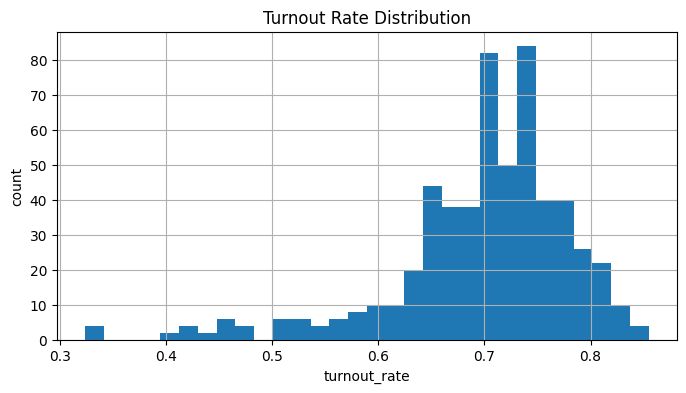

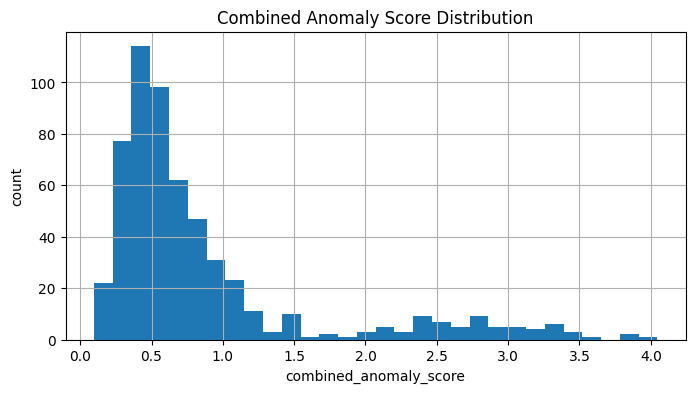

In [ ]:
# Optional quick EDA charts
# Run this cell when you want to inspect distributions visually.

try:
    import matplotlib.pyplot as plt

    normal_features = features[features["unit_type"].eq("normal_precinct")].copy()

    plt.figure(figsize=(8, 4))
    normal_features["turnout_rate"].dropna().hist(bins=30)
    plt.title("Turnout Rate Distribution")
    plt.xlabel("turnout_rate")
    plt.ylabel("count")
    plt.show()

    plt.figure(figsize=(8, 4))
    normal_features["combined_anomaly_score"].dropna().hist(bins=30)
    plt.title("Combined Anomaly Score Distribution")
    plt.xlabel("combined_anomaly_score")
    plt.ylabel("count")
    plt.show()

except Exception as e:
    print("EDA charts skipped:", e)


In [ ]:
# =========================
# View all audit units
# =========================

audit_table


,audit_level,audit_category,serious_flags,warning_flags,rule_flags,unit_index,display_name,election_type,unit_type,district,...,serious_flag_count,warning_flag_count,rule_flag_count,z_anomaly_score,max_abs_z,isolation_forest_label,isolation_forest_score,combined_anomaly_score,latitude,longitude
156,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_15_25,ปี 2569 / partylist / แม่อาย / ท่าตอน / 15 / ห...,partylist,normal_precinct,แม่อาย,...,0,1,1,1.547020,5.323346,anomaly,0.671721,4.047020,20.074763,99.491960
449,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_15_24,ปี 2569 / constituency / แม่อาย / ท่าตอน / 15 ...,constituency,normal_precinct,แม่อาย,...,0,1,1,1.424066,4.970916,anomaly,0.649190,3.848949,20.076635,99.488296
578,high_review,model_and_score_high_anomaly,,very_high_winner_share,very_high_winner_share,50_เชียงใหม่_7_ไชยปราการ_แม่ทะลบ_8_11,ปี 2569 / constituency / ไชยปราการ / แม่ทะลบ /...,constituency,normal_precinct,ไชยปราการ,...,0,1,1,1.366693,4.697797,anomaly,0.665452,3.845792,19.724211,99.198448
450,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_15_25,ปี 2569 / constituency / แม่อาย / ท่าตอน / 15 ...,constituency,normal_precinct,แม่อาย,...,0,1,1,1.279166,4.041231,anomaly,0.627445,3.631548,20.074763,99.491960
116,high_review,model_and_score_high_anomaly,,low_turnout_rate,low_turnout_rate,50_เชียงใหม่_7_ฝาง_แม่งอน_9_11,ปี 2569 / partylist / ฝาง / แม่งอน / 9 / หน่วย 11,partylist,normal_precinct,ฝาง,...,0,1,1,1.185957,4.339443,anomaly,0.617510,3.505215,19.807103,99.123667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,review,statistical_review,,,,50_เชียงใหม่_7_แม่อาย_บ้านหลวง_3_4,ปี 2569 / partylist / แม่อาย / บ้านหลวง / 3 / ...,partylist,normal_precinct,แม่อาย,...,0,0,0,0.553101,1.631607,normal,0.481839,0.920030,19.910450,99.295284
533,review,statistical_review,,,,50_เชียงใหม่_7_แม่อาย_แม่สาว_4_4,ปี 2569 / constituency / แม่อาย / แม่สาว / 4 /...,constituency,normal_precinct,แม่อาย,...,0,0,0,0.581475,1.366100,normal,0.473065,0.919151,20.001406,99.262143
516,review,statistical_review,,,,50_เชียงใหม่_7_แม่อาย_แม่นาวาง_6_7,ปี 2569 / constituency / แม่อาย / แม่นาวาง / 6...,constituency,normal_precinct,แม่อาย,...,0,0,0,0.601037,1.723226,normal,0.466267,0.916050,19.989695,99.383654
461,review,statistical_review,,,,50_เชียงใหม่_7_แม่อาย_ท่าตอน_8_12,ปี 2569 / constituency / แม่อาย / ท่าตอน / 8 /...,constituency,normal_precinct,แม่อาย,...,0,0,0,0.566520,1.717277,normal,0.475195,0.911300,20.069975,99.445600


In [ ]:
# หน่วยที่ต้อง review ระดับกลาง
# เปิดดูไฟล์ audit_review_units_clean.csv ได้ด้วย

audit_review_units


,audit_level,audit_category,serious_flags,warning_flags,rule_flags,unit_index,display_name,election_type,unit_type,district,...,serious_flag_count,warning_flag_count,rule_flag_count,z_anomaly_score,max_abs_z,isolation_forest_label,isolation_forest_score,combined_anomaly_score,latitude,longitude
281,review,statistical_review,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_ไชยปราการ_แม่ทะลบ_6_8,ปี 2569 / partylist / ไชยปราการ / แม่ทะลบ / 6 ...,partylist,normal_precinct,ไชยปราการ,...,0,1,1,0.625333,1.717580,normal,0.488836,2.515590,19.734173,99.180360
212,review,statistical_review,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_แม่นาวาง_13_17,ปี 2569 / partylist / แม่อาย / แม่นาวาง / 13 /...,partylist,normal_precinct,แม่อาย,...,0,1,1,0.630021,1.536387,normal,0.479875,2.490402,20.001998,99.418796
147,review,statistical_review,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_10_16,ปี 2569 / partylist / แม่อาย / ท่าตอน / 10 / ห...,partylist,normal_precinct,แม่อาย,...,0,1,1,0.594658,1.563200,normal,0.482122,2.462532,20.056517,99.364070
334,review,statistical_review,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_ฝาง_สันทราย_9_10,ปี 2569 / constituency / ฝาง / สันทราย / 9 / ห...,constituency,normal_precinct,ฝาง,...,0,1,1,0.612299,1.899906,normal,0.470808,2.442450,19.886585,99.183805
528,review,statistical_review,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_แม่สาว_15_16,ปี 2569 / constituency / แม่อาย / แม่สาว / 15 ...,constituency,normal_precinct,แม่อาย,...,0,1,1,0.604222,2.069546,normal,0.471882,2.437953,19.963989,99.246830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,review,statistical_review,,,,50_เชียงใหม่_7_แม่อาย_บ้านหลวง_3_4,ปี 2569 / partylist / แม่อาย / บ้านหลวง / 3 / ...,partylist,normal_precinct,แม่อาย,...,0,0,0,0.553101,1.631607,normal,0.481839,0.920030,19.910450,99.295284
533,review,statistical_review,,,,50_เชียงใหม่_7_แม่อาย_แม่สาว_4_4,ปี 2569 / constituency / แม่อาย / แม่สาว / 4 /...,constituency,normal_precinct,แม่อาย,...,0,0,0,0.581475,1.366100,normal,0.473065,0.919151,20.001406,99.262143
516,review,statistical_review,,,,50_เชียงใหม่_7_แม่อาย_แม่นาวาง_6_7,ปี 2569 / constituency / แม่อาย / แม่นาวาง / 6...,constituency,normal_precinct,แม่อาย,...,0,0,0,0.601037,1.723226,normal,0.466267,0.916050,19.989695,99.383654
461,review,statistical_review,,,,50_เชียงใหม่_7_แม่อาย_ท่าตอน_8_12,ปี 2569 / constituency / แม่อาย / ท่าตอน / 8 /...,constituency,normal_precinct,แม่อาย,...,0,0,0,0.566520,1.717277,normal,0.475195,0.911300,20.069975,99.445600


In [ ]:
# หน่วยที่ต้อง high_review และหน่วยที่มี serious_flags
# เปิดดูไฟล์ audit_high_review_units_clean.csv และ audit_serious_flags_clean.csv ได้ด้วย

print("High review units:", len(audit_high_review_units))
print("Serious flag units:", len(audit_serious_flags))

display(audit_high_review_units)
display(audit_serious_flags)


High review units: 46
Serious flag units: 0


,audit_level,audit_category,serious_flags,warning_flags,rule_flags,unit_index,display_name,election_type,unit_type,district,...,serious_flag_count,warning_flag_count,rule_flag_count,z_anomaly_score,max_abs_z,isolation_forest_label,isolation_forest_score,combined_anomaly_score,latitude,longitude
156,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_15_25,ปี 2569 / partylist / แม่อาย / ท่าตอน / 15 / ห...,partylist,normal_precinct,แม่อาย,...,0,1,1,1.547020,5.323346,anomaly,0.671721,4.047020,20.074763,99.491960
449,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_15_24,ปี 2569 / constituency / แม่อาย / ท่าตอน / 15 ...,constituency,normal_precinct,แม่อาย,...,0,1,1,1.424066,4.970916,anomaly,0.649190,3.848949,20.076635,99.488296
578,high_review,model_and_score_high_anomaly,,very_high_winner_share,very_high_winner_share,50_เชียงใหม่_7_ไชยปราการ_แม่ทะลบ_8_11,ปี 2569 / constituency / ไชยปราการ / แม่ทะลบ /...,constituency,normal_precinct,ไชยปราการ,...,0,1,1,1.366693,4.697797,anomaly,0.665452,3.845792,19.724211,99.198448
450,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_15_25,ปี 2569 / constituency / แม่อาย / ท่าตอน / 15 ...,constituency,normal_precinct,แม่อาย,...,0,1,1,1.279166,4.041231,anomaly,0.627445,3.631548,20.074763,99.491960
116,high_review,model_and_score_high_anomaly,,low_turnout_rate,low_turnout_rate,50_เชียงใหม่_7_ฝาง_แม่งอน_9_11,ปี 2569 / partylist / ฝาง / แม่งอน / 9 / หน่วย 11,partylist,normal_precinct,ฝาง,...,0,1,1,1.185957,4.339443,anomaly,0.617510,3.505215,19.807103,99.123667
149,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_11_18,ปี 2569 / partylist / แม่อาย / ท่าตอน / 11 / ห...,partylist,normal_precinct,แม่อาย,...,0,1,1,1.152770,3.569151,anomaly,0.610338,3.448117,20.059777,99.385511
155,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_15_24,ปี 2569 / partylist / แม่อาย / ท่าตอน / 15 / ห...,partylist,normal_precinct,แม่อาย,...,0,1,1,1.154656,3.499083,anomaly,0.598136,3.409322,20.076635,99.488296
148,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_ท่าตอน_11_17,ปี 2569 / partylist / แม่อาย / ท่าตอน / 11 / ห...,partylist,normal_precinct,แม่อาย,...,0,1,1,1.131282,3.241309,anomaly,0.595372,3.376732,20.054606,99.368309
547,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_แม่อาย_3_1,ปี 2569 / constituency / แม่อาย / แม่อาย / 3 /...,constituency,normal_precinct,แม่อาย,...,0,1,1,1.039365,3.767068,anomaly,0.596856,3.289764,20.024419,99.278412
234,high_review,model_and_score_high_anomaly,,high_invalid_rate,high_invalid_rate,50_เชียงใหม่_7_แม่อาย_แม่สาว_15_16,ปี 2569 / partylist / แม่อาย / แม่สาว / 15 / ห...,partylist,normal_precinct,แม่อาย,...,0,1,1,1.039631,3.049709,anomaly,0.594313,3.281551,19.963989,99.246830


,audit_level,audit_category,serious_flags,warning_flags,rule_flags,unit_index,display_name,election_type,unit_type,district,...,serious_flag_count,warning_flag_count,rule_flag_count,z_anomaly_score,max_abs_z,isolation_forest_label,isolation_forest_score,combined_anomaly_score,latitude,longitude


## Step 19 — Pipeline เตรียมข้อมูลปี 2566 ให้เป็น final schema เดียวกับปี 2569

ส่วนนี้อ่าน `election_scores_2566.csv` และ `election_locations_66.csv` แล้วสร้างตาราง final ของปี 2566 ให้มี schema เดียวกับ final ปี 2569 เพื่อใช้รวมใน BI / visualization ได้ง่าย

หมายเหตุ: ไฟล์ปี 2566 เป็น wide table และเพิ่ม mapping รายชื่อผู้สมัครเขต 7 จากข้อมูลที่ให้มา ที่มีคอลัมน์คะแนนแบบ `บช_...` และ `เขต_...` อยู่ในแถวเดียวกัน จึงต้องแยกออกเป็น `partylist` และ `constituency` ก่อน


In [ ]:

# =========================
# Year 2566 pipeline helpers
# =========================

PARTY_COLORS.setdefault("ก้าวไกล", [255, 120, 0, 190])

# Candidate mapping for Chiang Mai district 7, general election 2566.
# ใช้กับ constituency ปี 2566 เพราะไฟล์คะแนนเก็บคะแนนตามพรรค แต่ไม่ได้มีชื่อผู้สมัครใน column
CANDIDATE_MAP_66 = {
    "ก้าวไกล": {"candidate_no": 2, "candidate": "สมดุลย์ อุตเจริญ"},
    "เพื่อไทย": {"candidate_no": 7, "candidate": "นิธิกร วุฒินันชัย"},
    "รวมไทยสร้างชาติ": {"candidate_no": 1, "candidate": "สันติ ตันสุหัช"},
    "ประชาธิปัตย์": {"candidate_no": 5, "candidate": "นิคม เชาว์กิตติโสภณ"},
    "รวมแผ่นดิน": {"candidate_no": 4, "candidate": "เทวิกา ชัยชนะ"},
    "เพื่อชาติ": {"candidate_no": 3, "candidate": "คณาฤทธิ์ สุภาคุณ"},
    "ไทยสร้างไทย": {"candidate_no": 6, "candidate": "วรโชติ จี้เรือน"},
    "พลังประชารัฐ": {"candidate_no": 13, "candidate": "บดินทร์ กินาวงศ์"},
    "เสรีรวมไทย": {"candidate_no": 9, "candidate": "ชัยประเสริฐศิริ ทองสนิท"},
    "ไทยภักดี": {"candidate_no": 12, "candidate": "สมศักดิ์ ปัญญา"},
    "พลังบูรพา": {"candidate_no": 11, "candidate": "ไพรัตน์ ธรรมธิ"},
    "ภูมิใจไทย": {"candidate_no": 8, "candidate": "ศรัณย์ แสนพรหม"},
    "ไทยศรีวิไลย์": {"candidate_no": 10, "candidate": "กรินท์ บุญตันสา"},
}

# เรียงตามหมายเลขผู้สมัคร ไม่ใช่ตามลำดับ column ในไฟล์
CONSTITUENCY_PARTIES_66 = [
    party for party, meta in sorted(CANDIDATE_MAP_66.items(), key=lambda x: x[1]["candidate_no"])
]
CONSTITUENCY_VOTE_COLS_66 = [f"เขต_{party}" for party in CONSTITUENCY_PARTIES_66]



def get_vote_columns_66(df: pd.DataFrame, prefix: str) -> list:
    """Return vote columns from election_scores_2566.csv for one election type.

    prefix = "บช" for party list, "เขต" for constituency.
    For constituency, keep only the 13 registered candidates in Chiang Mai district 7.
    This prevents unrelated province-wide party columns with zeros from entering the results JSON.
    """
    if prefix == "เขต":
        missing_cols = [c for c in CONSTITUENCY_VOTE_COLS_66 if c not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing constituency candidate vote columns for year 66: {missing_cols}")
        return CONSTITUENCY_VOTE_COLS_66.copy()

    excluded = {
        f"{prefix}_ผู้มีสิทธิ์",
        f"{prefix}_ผู้มาใช้สิทธิ์",
        f"{prefix}_บัตรเสีย",
        f"{prefix}_ไม่เลือกผู้ใด",
    }
    return [c for c in df.columns if c.startswith(f"{prefix}_") and c not in excluded]


def prepare_scores_66(scores66_raw: pd.DataFrame, province="เชียงใหม่", district_no=7) -> pd.DataFrame:
    """Filter year 2566 scores to Chiang Mai district 7 and tag advance rows."""
    df = scores66_raw.copy()
    df = df[(df["province"].eq(province)) & (df["province_number"].eq(district_no))].copy()

    df["is_advance"] = (
        df["registrar"].astype(str).str.contains("ล่วงหน้านอกเขต", na=False)
        | df["district"].isna()
    )

    # ปี 2566 ไม่มีหมายเลขชุดล่วงหน้าในไฟล์นี้ จึงสร้าง set_no ตามลำดับแถว advance
    df["set_no"] = np.nan
    advance_idx = df[df["is_advance"]].sort_values("id").index
    df.loc[advance_idx, "set_no"] = range(1, len(advance_idx) + 1)

    return df.reset_index(drop=True)


def make_unit_index_66(row, is_advance=False):
    """Create unit_index for year 2566.

    ปี 2566 ไม่มี column หมู่ จึงใส่ NA ในตำแหน่งหมู่ และใช้ registrar เพื่อกัน key ซ้ำ
    ระหว่าง อำเภอ/เทศบาล ที่มีตำบลและเลขหน่วยซ้ำกัน
    """
    if is_advance:
        set_no = int(float(row["set_no"]))
        return f"50_เชียงใหม่_7_ล่วงหน้านอกเขตและนอกราชอาณาจักร_{set_no}"

    registrar = clean_text(row.get("registrar"))
    subdistrict = clean_text(row.get("subdistrict"))
    precinct_no = int(float(row.get("station_number")))
    return f"50_เชียงใหม่_7_{registrar}_{subdistrict}_NA_{precinct_no}"


def prepare_location_lookup_66(loc66_raw: pd.DataFrame) -> pd.DataFrame:
    """Create lookup from 2566 location file by registrar/subdistrict/precinct."""
    loc = loc66_raw.copy()
    loc = loc[(loc["provinceid"].eq(50)) & (loc["divisionnumber"].eq(7))].copy()

    # districtid เหล่านี้เป็นเทศบาลตำบลในเขต 7 จึงต้อง map ให้ตรงกับ registrar ใน scores file
    municipal_ids = {500787, 500788, 500786, 500772}
    loc["registrar_key"] = np.where(
        loc["districtid"].isin(municipal_ids),
        "ท้องถิ่นเทศบาลตำบล" + loc["districtname"].astype(str),
        "อำเภอ" + loc["districtname"].astype(str),
    )

    loc["subdistrict_norm"] = loc["subdistrictname"].map(normalize_subdistrict)
    loc["precinct_no"] = pd.to_numeric(loc["unitid"].astype(str).str[-2:], errors="coerce").astype("Int64")
    loc["latitude"] = pd.to_numeric(loc["lat_changable"], errors="coerce")
    loc["longitude"] = pd.to_numeric(loc["lng_changable"], errors="coerce")

    lookup = loc[[
        "registrar_key", "subdistrict_norm", "precinct_no",
        "latitude", "longitude", "unitname"
    ]].dropna(subset=["latitude", "longitude"]).copy()

    # one row per precinct key
    lookup = lookup.drop_duplicates(["registrar_key", "subdistrict_norm", "precinct_no"], keep="first")
    return lookup


def lookup_lat_lng_66(row, loc_lookup66: pd.DataFrame):
    if bool(row.get("is_advance")):
        return pd.Series({"latitude": np.nan, "longitude": np.nan})

    registrar_key = clean_text(row.get("registrar"))
    subdistrict_norm = normalize_subdistrict(row.get("subdistrict"))
    precinct_no = int(float(row.get("station_number")))

    m = loc_lookup66[
        loc_lookup66["registrar_key"].eq(registrar_key)
        & loc_lookup66["subdistrict_norm"].eq(subdistrict_norm)
        & loc_lookup66["precinct_no"].astype("Int64").eq(precinct_no)
    ]

    if len(m) == 0:
        return pd.Series({"latitude": np.nan, "longitude": np.nan})

    return pd.Series({
        "latitude": float(m.iloc[0]["latitude"]),
        "longitude": float(m.iloc[0]["longitude"]),
    })


def build_final_66_for_type(scores66: pd.DataFrame, loc_lookup66: pd.DataFrame, election_type: str) -> pd.DataFrame:
    """Build final rows for one election type in year 2566."""
    prefix = "บช" if election_type == "partylist" else "เขต"
    vote_cols = get_vote_columns_66(scores66, prefix)

    rows = []
    for _, r in scores66.iterrows():
        is_advance = bool(r["is_advance"])
        unit_index = make_unit_index_66(r, is_advance=is_advance)

        records = []
        for order, col in enumerate(vote_cols, start=1):
            party = col.replace(f"{prefix}_", "", 1)
            votes = to_int_or_nan(r.get(col))
            votes = 0 if pd.isna(votes) else int(votes)

            if election_type == "partylist":
                records.append({"party_no": order, "party": party, "votes": votes})
            else:
                candidate_meta = CANDIDATE_MAP_66.get(party, {})
                records.append({
                    "candidate_no": candidate_meta.get("candidate_no", order),
                    "candidate": candidate_meta.get("candidate", np.nan),
                    "party": party,
                    "votes": votes,
                })

        s = summarize_results(records, election_type)
        s["unit_index"] = unit_index
        s["year"] = 2566
        s["election_type"] = election_type
        s["unit_type"] = "advance_set" if is_advance else "normal_precinct"
        s["district"] = "เขต 7" if is_advance else clean_text(r.get("district"))
        s["subdistrict"] = np.nan if is_advance else clean_text(r.get("subdistrict"))
        s["village_no"] = np.nan  # source ปี 2566 ไม่มีหมู่
        s["precinct_no"] = np.nan if is_advance else int(float(r.get("station_number")))
        s["set_no"] = int(float(r["set_no"])) if is_advance else np.nan

        lat_lng = lookup_lat_lng_66(r, loc_lookup66)
        s["latitude"] = lat_lng["latitude"]
        s["longitude"] = lat_lng["longitude"]
        rows.append(s)

    out = pd.DataFrame(rows)
    out["color"] = out["winner_party"].map(lambda x: PARTY_COLORS.get(x, DEFAULT_COLOR))

    def make_display_name_66(r):
        if r["unit_type"] == "advance_set":
            return f"ปี 2566 / {r['election_type']} / ล่วงหน้า / ชุด {int(r['set_no'])}"
        return f"ปี 2566 / {r['election_type']} / {r['district']} / {r['subdistrict']} / หน่วย {int(r['precinct_no'])}"

    out["display_name"] = out.apply(make_display_name_66, axis=1)
    return out[FINAL_COLUMNS]


def build_final_66(scores66: pd.DataFrame, loc_lookup66: pd.DataFrame) -> pd.DataFrame:
    parts = [
        build_final_66_for_type(scores66, loc_lookup66, "partylist"),
        build_final_66_for_type(scores66, loc_lookup66, "constituency"),
    ]
    final66 = pd.concat(parts, ignore_index=True)

    final66["_election_order"] = final66["election_type"].map({"partylist": 0, "constituency": 1})
    final66["_unit_order"] = final66["unit_type"].map({"normal_precinct": 0, "advance_set": 1})
    final66 = final66.sort_values(
        ["year", "_election_order", "_unit_order", "district", "subdistrict", "precinct_no", "set_no"],
        na_position="last",
    )
    final66 = final66[FINAL_COLUMNS].reset_index(drop=True)
    final66["latitude"] = final66["latitude"].round(6)
    final66["longitude"] = final66["longitude"].round(6)
    return final66


## Step 20 — Build final ปี 2566 และจำนวนบัตร

สร้าง `final_66`, `ballot_long_66`, และ `final_66_with_ballots` โดยใช้คอลัมน์จำนวนบัตรจาก `election_scores_2566.csv` โดยตรง


In [ ]:

# =========================
# Build year 2566 final + ballot counts
# =========================

scores66_raw = read_csv_clean(INPUT_FILES["election_scores_66"])
loc66_for_year66_raw = read_csv_clean(INPUT_FILES["location_66"])

scores66 = prepare_scores_66(scores66_raw, province="เชียงใหม่", district_no=7)
loc_lookup66 = prepare_location_lookup_66(loc66_for_year66_raw)

final_66 = build_final_66(scores66, loc_lookup66)

print("Final 66 shape:", final_66.shape)
print(final_66.groupby(["election_type", "unit_type"]).size())
print("Missing lat/lng in normal precincts:", final_66[final_66["unit_type"].eq("normal_precinct")][["latitude", "longitude"]].isna().any(axis=1).sum())

final_66.head()


Final 66 shape: (526, 21)
election_type  unit_type      
constituency   advance_set          8
               normal_precinct    255
partylist      advance_set          8
               normal_precinct    255
dtype: int64
Missing lat/lng in normal precincts: 0


,unit_index,year,election_type,unit_type,district,subdistrict,village_no,precinct_no,set_no,latitude,...,winner_party,winner_candidate,winner_votes,runner_up_party,runner_up_votes,margin,total_votes_in_file,results,color,display_name
0,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_1,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,1.0,NaN,19.915875,...,ก้าวไกล,NaN,0,เสรีรวมไทย,0,0,0,"[{""party_no"": 1, ""party"": ""ก้าวไกล"", ""votes"": ...","[255, 120, 0, 190]",ปี 2566 / partylist / ฝาง / ม่อนปิ่น / หน่วย 1
1,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_2,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,2.0,NaN,19.912379,...,ก้าวไกล,NaN,183,เพื่อไทย,78,105,323,"[{""party_no"": 1, ""party"": ""ก้าวไกล"", ""votes"": ...","[255, 120, 0, 190]",ปี 2566 / partylist / ฝาง / ม่อนปิ่น / หน่วย 2
2,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_3,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,3.0,NaN,19.915887,...,ก้าวไกล,NaN,207,เพื่อไทย,172,35,427,"[{""party_no"": 1, ""party"": ""ก้าวไกล"", ""votes"": ...","[255, 120, 0, 190]",ปี 2566 / partylist / ฝาง / ม่อนปิ่น / หน่วย 3
3,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_4,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,4.0,NaN,19.904352,...,ก้าวไกล,NaN,65,เพื่อไทย,45,20,125,"[{""party_no"": 1, ""party"": ""ก้าวไกล"", ""votes"": ...","[255, 120, 0, 190]",ปี 2566 / partylist / ฝาง / ม่อนปิ่น / หน่วย 4
4,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_5,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,5.0,NaN,19.964906,...,ก้าวไกล,NaN,313,เพื่อไทย,121,192,493,"[{""party_no"": 1, ""party"": ""ก้าวไกล"", ""votes"": ...","[255, 120, 0, 190]",ปี 2566 / partylist / ฝาง / ม่อนปิ่น / หน่วย 5


## Step 21 — Join จำนวนบัตรปี 2566 และ export

`valid_ballots` ของปี 2566 คำนวณจาก `ผู้มาใช้สิทธิ์ - บัตรเสีย - ไม่เลือกผู้ใด` ส่วน `total_votes_in_file` คือผลรวมคะแนนจากคอลัมน์พรรค/ผู้สมัครที่มีอยู่ในไฟล์คะแนนปี 2566


In [ ]:

def build_ballot_long_66(scores66: pd.DataFrame) -> pd.DataFrame:
    """Build ballot-count long table for year 2566 from election_scores_2566.csv."""
    parts = []

    for election_type, prefix in [("partylist", "บช"), ("constituency", "เขต")]:
        vote_cols = get_vote_columns_66(scores66, prefix)
        part = scores66[["district", "subdistrict", "registrar", "station_number", "is_advance", "set_no"]].copy()
        part["election_type"] = election_type
        part["unit_type"] = np.where(part["is_advance"], "advance_set", "normal_precinct")
        part["unit_index"] = scores66.apply(lambda r: make_unit_index_66(r, bool(r["is_advance"])), axis=1)

        part["eligible_voters"] = scores66[f"{prefix}_ผู้มีสิทธิ์"].map(to_int_or_nan)
        part["appeared_voters"] = scores66[f"{prefix}_ผู้มาใช้สิทธิ์"].map(to_int_or_nan)
        part["invalid_ballots"] = scores66[f"{prefix}_บัตรเสีย"].map(to_int_or_nan)
        part["no_vote_ballots"] = scores66[f"{prefix}_ไม่เลือกผู้ใด"].map(to_int_or_nan)
        part["used_ballots"] = part["appeared_voters"]
        part["valid_ballots"] = part["appeared_voters"] - part["invalid_ballots"] - part["no_vote_ballots"]

        # ปี 2566 source นี้ไม่มี allocated/remaining ในไฟล์คะแนน
        part["allocated_ballots"] = np.nan
        part["remaining_ballots"] = np.nan

        # เก็บไว้ช่วยตรวจว่า vote columns ในไฟล์ครอบคลุมบัตรดีทั้งหมดหรือไม่
        vote_sum = scores66[vote_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
        part["available_vote_sum_66"] = vote_sum.astype(int)
        part["valid_ballots_gap_from_available_votes_66"] = part["valid_ballots"] - part["available_vote_sum_66"]

        parts.append(part[["unit_index", "election_type", "unit_type"] + BALLOT_COLUMNS + [
            "available_vote_sum_66",
            "valid_ballots_gap_from_available_votes_66",
        ]])

    out = pd.concat(parts, ignore_index=True)
    for col in BALLOT_COLUMNS + ["available_vote_sum_66", "valid_ballots_gap_from_available_votes_66"]:
        out[col] = pd.to_numeric(out[col], errors="coerce").astype("Int64")

    key_cols = ["unit_index", "election_type", "unit_type"]
    duplicated = out.duplicated(key_cols, keep=False)
    if duplicated.any():
        print("Warning: duplicated year 66 ballot keys found. Keeping the first row per key.")
        display(out.loc[duplicated].sort_values(key_cols).head(20))
        out = out.drop_duplicates(key_cols, keep="first")

    return out


def add_basic_ballot_features_66(final66: pd.DataFrame, ballot_long66: pd.DataFrame) -> pd.DataFrame:
    """Join ballot counts and create rate/check columns for year 2566."""
    df = final66.merge(ballot_long66, on=["unit_index", "election_type", "unit_type"], how="left")

    df["turnout_rate"] = safe_div(df["appeared_voters"], df["eligible_voters"])
    df["used_ballot_rate"] = safe_div(df["used_ballots"], df["allocated_ballots"])
    df["valid_rate"] = safe_div(df["valid_ballots"], df["used_ballots"])
    df["invalid_rate"] = safe_div(df["invalid_ballots"], df["used_ballots"])
    df["no_vote_rate"] = safe_div(df["no_vote_ballots"], df["used_ballots"])
    df["remaining_rate"] = safe_div(df["remaining_ballots"], df["allocated_ballots"])
    df["winner_share"] = safe_div(df["winner_votes"], df["total_votes_in_file"])
    df["runner_up_share"] = safe_div(df["runner_up_votes"], df["total_votes_in_file"])
    df["margin_rate"] = safe_div(df["margin"], df["total_votes_in_file"])
    df["competitiveness"] = 1 - df["margin_rate"]

    df["vote_mismatch"] = pd.to_numeric(df["valid_ballots"], errors="coerce") - pd.to_numeric(df["total_votes_in_file"], errors="coerce")
    df["abs_vote_mismatch"] = df["vote_mismatch"].abs()
    df["ballot_equation_error"] = pd.to_numeric(df["used_ballots"], errors="coerce") - (
        pd.to_numeric(df["valid_ballots"], errors="coerce")
        + pd.to_numeric(df["invalid_ballots"], errors="coerce")
        + pd.to_numeric(df["no_vote_ballots"], errors="coerce")
    )
    df["allocation_equation_error"] = pd.to_numeric(df["allocated_ballots"], errors="coerce") - (
        pd.to_numeric(df["used_ballots"], errors="coerce")
        + pd.to_numeric(df["remaining_ballots"], errors="coerce")
    )
    df["appeared_used_error"] = pd.to_numeric(df["appeared_voters"], errors="coerce") - pd.to_numeric(df["used_ballots"], errors="coerce")

    # ปี 2566 ไม่ run anomaly model ใน cell นี้ เพราะ source คะแนนเป็น wide table และบางประเภทมีเฉพาะพรรค/ผู้สมัครที่อยู่ในไฟล์
    df["audit_level"] = "not_run_for_66"
    df["audit_category"] = "year66_prepared_final_only"
    df["serious_flags"] = ""
    df["warning_flags"] = np.where(
        pd.to_numeric(df["valid_ballots_gap_from_available_votes_66"], errors="coerce").fillna(0).ne(0),
        "available_vote_columns_do_not_sum_to_official_valid_ballots",
        "",
    )
    df["rule_flags"] = df["warning_flags"]
    df["serious_flag_count"] = 0
    df["warning_flag_count"] = df["warning_flags"].apply(lambda x: 0 if x == "" else len(str(x).split("|")))
    df["rule_flag_count"] = df["warning_flag_count"]
    df["z_anomaly_score"] = np.nan
    df["max_abs_z"] = np.nan
    df["isolation_forest_label"] = "not_run_for_66"
    df["isolation_forest_score"] = np.nan
    df["combined_anomaly_score"] = np.nan

    return df


ballot_long_66 = build_ballot_long_66(scores66)
final_66_with_ballots = add_basic_ballot_features_66(final_66, ballot_long_66)

final_66.to_csv(OUTPUT_FILES["final_66"], index=False, encoding="utf-8-sig")
ballot_long_66.to_csv(OUTPUT_FILES["ballot_long_66"], index=False, encoding="utf-8-sig")
final_66_with_ballots.to_csv(OUTPUT_FILES["final_66_with_ballots"], index=False, encoding="utf-8-sig")

print("Year 66 saved files:")
print("-", OUTPUT_FILES["final_66"])
print("-", OUTPUT_FILES["ballot_long_66"])
print("-", OUTPUT_FILES["final_66_with_ballots"])
print("\nFinal 66 with ballots shape:", final_66_with_ballots.shape)
print(final_66_with_ballots.groupby(["election_type", "unit_type"]).size())
print("\nWarning flags 66:")
print(final_66_with_ballots["warning_flags"].value_counts(dropna=False).head())

final_66_with_ballots.head()


Year 66 saved files:
- final_2566_clean.csv
- ballot_long_2566_clean.csv
- final_with_ballots_2566_clean.csv

Final 66 with ballots shape: (526, 59)
election_type  unit_type      
constituency   advance_set          8
               normal_precinct    255
partylist      advance_set          8
               normal_precinct    255
dtype: int64

Warning flags 66:
warning_flags
available_vote_columns_do_not_sum_to_official_valid_ballots    300
                                                               226
Name: count, dtype: int64


,unit_index,year,election_type,unit_type,district,subdistrict,village_no,precinct_no,set_no,latitude,...,warning_flags,rule_flags,serious_flag_count,warning_flag_count,rule_flag_count,z_anomaly_score,max_abs_z,isolation_forest_label,isolation_forest_score,combined_anomaly_score
0,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_1,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,1.0,NaN,19.915875,...,,,0,0,0,NaN,NaN,not_run_for_66,NaN,NaN
1,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_2,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,2.0,NaN,19.912379,...,available_vote_columns_do_not_sum_to_official_...,available_vote_columns_do_not_sum_to_official_...,0,1,1,NaN,NaN,not_run_for_66,NaN,NaN
2,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_3,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,3.0,NaN,19.915887,...,available_vote_columns_do_not_sum_to_official_...,available_vote_columns_do_not_sum_to_official_...,0,1,1,NaN,NaN,not_run_for_66,NaN,NaN
3,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_4,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,4.0,NaN,19.904352,...,available_vote_columns_do_not_sum_to_official_...,available_vote_columns_do_not_sum_to_official_...,0,1,1,NaN,NaN,not_run_for_66,NaN,NaN
4,50_เชียงใหม่_7_อำเภอฝาง_ม่อนปิ่น_NA_5,2566,partylist,normal_precinct,ฝาง,ม่อนปิ่น,NaN,5.0,NaN,19.964906,...,available_vote_columns_do_not_sum_to_official_...,available_vote_columns_do_not_sum_to_official_...,0,1,1,NaN,NaN,not_run_for_66,NaN,NaN


## Step 22 — Optional: รวม final ปี 2566 + 2569

ถ้า run pipeline ปี 2569 ด้านบนแล้ว cell นี้จะรวม `final` และ `features` ของปี 2569 เข้ากับ output ปี 2566 ให้เป็นไฟล์เดียวสำหรับทำ dashboard ข้ามปี


In [ ]:

# =========================
# Optional combined files: 2566 + 2569
# =========================

if "final" in globals():
    final_all_years = pd.concat([final_66, final], ignore_index=True, sort=False)
    final_all_years = final_all_years.sort_values(
        ["year", "election_type", "unit_type", "district", "subdistrict", "precinct_no", "set_no"],
        na_position="last",
    ).reset_index(drop=True)
    final_all_years.to_csv(OUTPUT_FILES["final_all_years"], index=False, encoding="utf-8-sig")
    print("Saved:", OUTPUT_FILES["final_all_years"], final_all_years.shape)
else:
    print("Skip final_all_years because variable `final` from year 2569 was not found.")

if "features" in globals():
    final_with_ballots_all_years = pd.concat([final_66_with_ballots, features], ignore_index=True, sort=False)
    final_with_ballots_all_years = final_with_ballots_all_years.sort_values(
        ["year", "election_type", "unit_type", "district", "subdistrict", "precinct_no", "set_no"],
        na_position="last",
    ).reset_index(drop=True)
    final_with_ballots_all_years.to_csv(OUTPUT_FILES["final_with_ballots_all_years"], index=False, encoding="utf-8-sig")
    print("Saved:", OUTPUT_FILES["final_with_ballots_all_years"], final_with_ballots_all_years.shape)
else:
    print("Skip final_with_ballots_all_years because variable `features` from year 2569 was not found.")


Saved: final_2566_2569_combined_clean.csv (1114, 21)
Saved: final_with_ballots_2566_2569_combined_clean.csv (1114, 59)
